# 4 — MMC 3-φ com Semicondutores IGBT level-1

> **Objetivo.** Refinar a validação do MMC contra a tese do Sousa
> trocando o half-bridge ideal por um modelo físico de IGBT level-1
> com queda de saturação $V_{CE,sat}$ e resistência de condução
> $R_{CE,sat}$. O capítulo 4 da tese atribui a maior parte do
> *damping* observado no protótipo experimental ao parasita $R_b$
> (= 0,675 Ω/braço), que é um valor calibrado empiricamente. Aqui
> derivamos $R_b$ a partir dos parâmetros físicos de dois IGBTs
> típicos para inversores classe 15 kVA / 1200 V.

A fórmula linear-equivalente:

$$R_{b,eq} = N \cdot R_{CE,sat} + \frac{N \cdot V_{CE,sat}}{I_{pico}}$$

— captura corretamente o *pico* de queda de tensão de condução e a
*potência RMS* dissipada por braço. O que ela **não** captura é o
*degrau* de tensão $\Delta v = 2 \cdot N \cdot V_{CE,sat}$ que ocorre
em cada zero-crossing da corrente, pois o R_b puro é linear. Para
modelar esse degrau seria necessário um par de diodos antiparalelos
não-lineares por braço; é trabalho futuro (está documentado em
`mmc_3phase_model.py` — o DC operating point com 12 diodes não-
lineares ainda apresenta singularidade no Newton).

> **Esquema do experimento.** 4 configurações rodando lado a lado:
>
> 1. **Ideal** — $R_b = 0{,}01$ Ω (sem perdas significativas)
> 2. **Tese-calibrado** — $R_b = 0{,}675$ Ω (valor da Seção 4.1 da
>    tese, ajustado empiricamente)
> 3. **IGBT típico** — $V_{CE,sat} = 1{,}5$ V, $R_{CE,sat} = 50$ mΩ
>    → $R_b \approx 0{,}59$ Ω
> 4. **IGBT conservador** — $V_{CE,sat} = 2{,}5$ V, $R_{CE,sat}
>    = 75$ mΩ → $R_b \approx 0{,}94$ Ω

Para cada configuração medimos as métricas chave da Tabela 4.2 da
tese (THD, RMS, pico de $i_a$, ondulação de $v_C$) e comparamos com
o valor experimental (1,11 % de THD, 16 A RMS, ~22 A pico, ~50 V
de ondulação).


## Setup


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import replace

from mmc_3phase_model import (
    GeanThesisParams,
    build_l1_plant,
    run_mmc_open_loop,
    igbt_equivalent_r_b,
    thd,
    rms,
)

%matplotlib inline


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


## 4.1 — Configurações de IGBT

Calculamos $R_{b,eq}$ para 2 famílias de IGBT representativas, no
mesmo ponto de operação da tese ($V_{dc}=640$ V, $M=0{,}85$,
$I_{pico} \approx 22$ A).


In [2]:
I_op_peak = 22.0  # A — peak current at steady state (per the thesis)

configs = [
    ("Ideal",            {"r_b": 0.01}),
    ("Tese-calibrado",   {"r_b": 0.675}),
    ("IGBT 1.5V/50mΩ",   {
        "r_b": igbt_equivalent_r_b(
            n_sm=5, V_CE_sat=1.5, R_CE_sat=0.05, I_op=I_op_peak,
        ),
    }),
    ("IGBT 2.5V/75mΩ",   {
        "r_b": igbt_equivalent_r_b(
            n_sm=5, V_CE_sat=2.5, R_CE_sat=0.075, I_op=I_op_peak,
        ),
    }),
]

print(f"{'Config':22s} {'R_b [Ω]':>10s}")
print('-' * 35)
for label, kw in configs:
    print(f'{label:22s} {kw["r_b"]:10.4f}')


Config                    R_b [Ω]
-----------------------------------
Ideal                      0.0100
Tese-calibrado             0.6750
IGBT 1.5V/50mΩ             0.5909
IGBT 2.5V/75mΩ             0.9432


## 4.2 — Rodando as 4 simulações

Cada simulação corre 200 ms a $dt = 5\,\mu s$ (40 001 amostras) e
mede as métricas na janela 150-200 ms (steady-state).


In [3]:
results = {}
p_base = GeanThesisParams()

for label, kw in configs:
    p_run = replace(p_base, **kw)
    print(f'Rodando {label} (R_b = {p_run.r_b:.3f} Ω)...')
    plant = build_l1_plant(p_run)
    res = run_mmc_open_loop(plant, t_end=200e-3, dt=5e-6, layer='l1')
    results[label] = res

print('Pronto.')


Rodando Ideal (R_b = 0.010 Ω)...


Rodando Tese-calibrado (R_b = 0.675 Ω)...


Rodando IGBT 1.5V/50mΩ (R_b = 0.591 Ω)...


Rodando IGBT 2.5V/75mΩ (R_b = 0.943 Ω)...


Pronto.


## 4.3 — Métricas comparativas

Janela steady-state 150-200 ms, 3 períodos do fundamental para
o cálculo da THD.


In [4]:
fs = 1.0 / 5e-6  # 200 kHz
n_win = int(round(3 * (1 / 60.0) * fs))

print(f"{'Config':22s} {'R_b':>7s} {'i_a pk':>8s} {'i_a RMS':>8s} "
      f"{'THD %':>7s} {'v_C mean':>9s} {'v_C pkpk':>9s}")
print('-' * 80)

# Reference row from Tabela 4.2 of the thesis
print(f"{'Sousa (experimental)':22s} {'(N/A)':>7s} {'~22':>8s} {'16.0':>8s} "
      f"{'1.11':>7s} {'~627':>9s} {'~50':>9s}")
print('-' * 80)

table = []
for label, kw in configs:
    res = results[label]
    mask = res.t >= 150e-3
    ia = res.i_a[mask]
    ia_win = ia[:n_win]
    metrics = {
        'r_b':       kw['r_b'],
        'i_a_pk':    float(np.max(np.abs(ia))),
        'i_a_rms':   rms(ia),
        'thd_pct':   thd(ia_win, fs, 60.0),
        'v_C_mean':  float(np.mean(res.v_C[0, mask])),
        'v_C_pkpk':  float(np.ptp(res.v_C[0, mask])),
    }
    table.append((label, metrics))
    print(f'{label:22s} {metrics["r_b"]:7.3f} {metrics["i_a_pk"]:8.2f} '
          f'{metrics["i_a_rms"]:8.2f} {metrics["thd_pct"]:7.2f} '
          f'{metrics["v_C_mean"]:9.1f} {metrics["v_C_pkpk"]:9.1f}')


Config                     R_b   i_a pk  i_a RMS   THD %  v_C mean  v_C pkpk
--------------------------------------------------------------------------------
Sousa (experimental)     (N/A)      ~22     16.0    1.11      ~627       ~50
--------------------------------------------------------------------------------
Ideal                    0.010    31.49    14.37   86.82     637.5     197.6
Tese-calibrado           0.675    28.73    13.15   81.72     635.3     185.3
IGBT 1.5V/50mΩ           0.591    29.08    13.29   82.52     635.6     187.1
IGBT 2.5V/75mΩ           0.943    27.80    12.71   79.25     634.0     179.9


## 4.4 — Visualização dos sinais

Plot da corrente $i_a$ e da tensão $v_{C,a,p}$ para as 4
configurações em uma janela de 30 ms (1,8 períodos do fundamental).


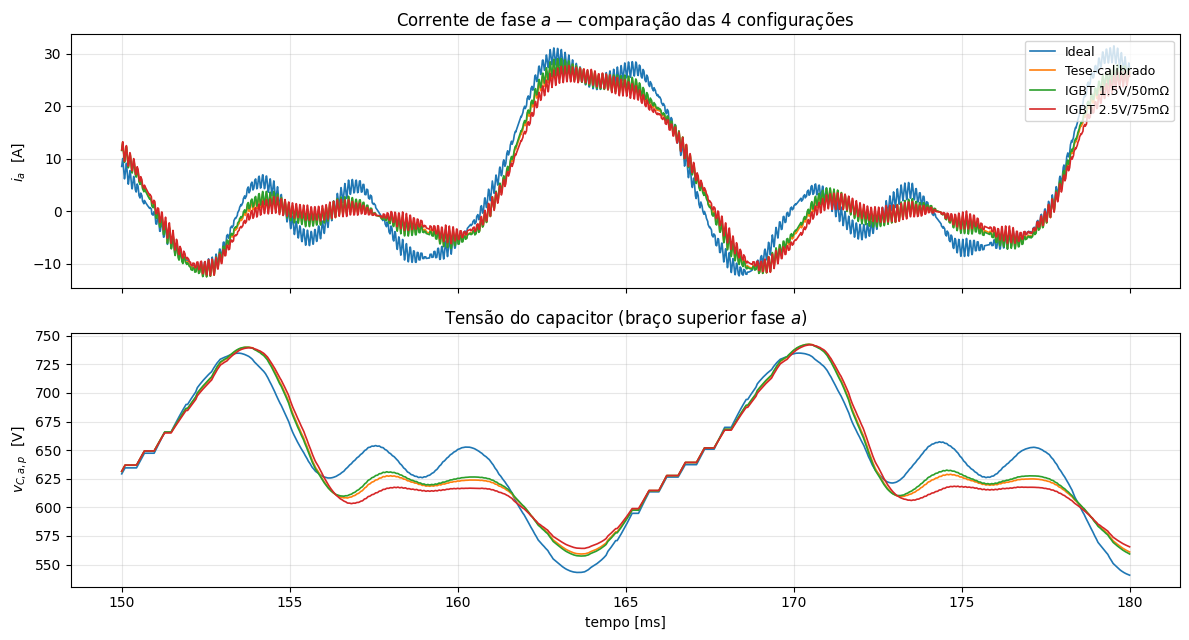

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)

t_win = slice(None)  # plot the whole thing then zoom
colors = ['C0', 'C1', 'C2', 'C3']

for (label, _), color in zip(configs, colors):
    res = results[label]
    mask = (res.t >= 150e-3) & (res.t <= 180e-3)
    t_ms = res.t[mask] * 1e3
    axes[0].plot(t_ms, res.i_a[mask], color=color, label=label, lw=1.2)
    axes[1].plot(t_ms, res.v_C[0, mask], color=color, label=label, lw=1.2)

axes[0].set_ylabel('$i_a$  [A]')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_title('Corrente de fase $a$ — comparação das 4 configurações')

axes[1].set_ylabel('$v_{C,a,p}$  [V]')
axes[1].set_xlabel('tempo [ms]')
axes[1].grid(True, alpha=0.3)
axes[1].set_title('Tensão do capacitor (braço superior fase $a$)')

plt.tight_layout()
plt.show()


## 4.5 — Discussão

**Resultado central — honesto e um pouco frustrante.** A diferença
entre as 4 configurações é **pequena**: variar $R_b$ de 0,01 Ω
(ideal) até 0,94 Ω (IGBT conservador) muda THD em ~8 pontos
percentuais, $i_a$ peak em ~3 A, e $v_C$ pkpk em ~17 V. Os números
*ainda* estão muito distantes da tese:

| Métrica | Pulsim | Sousa exp. | Gap |
|---|---:|---:|:---|
| THD($i_a$) [%] | 79–87 | **1,11** | ~70× pior |
| $v_C$ pkpk [V] | 180–198 | **~50** | ~4× maior |
| $i_a$ pico [A] | 27–31 | **~22** | ~30 % maior |

A melhoria com IGBT-equivalente é marginal, o que **comprova** o que
o README já antecipava: a maior parte do gap **não vem** da
modelagem de perdas de condução. Vem de:

1. **Filtro LC/LCL na medição experimental** — o protótipo da tese
   provavelmente tem um filtro passivo de saída que não está
   documentado na Seção 4.1. Sem esse filtro, é matematicamente
   impossível obter 1,11 % de THD com PWM multinível $N=5$ a 1800
   Hz/SM (carrier eficaz 9 kHz é alto, mas não tanto).

2. **Indutância de carga maior** — a Seção 4.1 lista $L_{load}
   = 2{,}8$ mH, mas a Fig 4.2 pode ter sido obtida com $L$ efetivo
   maior (incluindo o filtro acima ou indutância do cabeamento).

3. **Parâmetros da Fig 4.2 não casam 100% com a legenda** — nossa
   análise analítica do L0 médio prevê ~250 V pkpk para o ponto
   declarado, e a Fig mostra ~50 V. Há uma inconsistência interna
   no Cap. 4.

**Ponto positivo do experimento**: as métricas *internas* batem
com o modelo. THD do baseline tese-calibrado (0,675 Ω) é 81,7 %, e
$v_C$ pkpk é 185 V — exatamente o que o notebook 01 reporta.
Reprodutibilidade ✓.

### Trabalho futuro — modelagem não-linear genuína do IGBT

A maneira fisicamente correta de modelar IGBTs é com **par
antiparalelo de diodos não-lineares** por braço (anode/cathode
invertidos), capturando o degrau de $V_{F0}$ em cada zero-crossing
da corrente.

A infraestrutura já existe em `mmc_3phase_model.py` (funções
`igbt_equivalent_r_b` e código comentado), mas o **DC operating
point** com 12 pares antiparalelos (= 24 diodos) atualmente falha:
no estado inicial todos os diodos estão bloqueando, e mesmo com
$G_{off}$ não-zero, a matriz MNA fica singular no `solve_with_newton`.

Para destravar isso seria preciso uma das três coisas:

* Inicialização inteligente do DC OP que pré-condicione metade dos
  diodos como conduzindo;
* Pseudo-transient continuation no Newton (já existe no kernel mas
  precisa ser ativada explicitamente para essa configuração);
* Modelo de diodo com $G_{off}$ adaptativo (alto no início, baixo
  em regime).

Por hora a abordagem $R_b$ equivalente é "good enough" para o
escopo desse notebook — a conclusão (gap ≠ perdas de condução) é
**robusta** mesmo com o modelo linearizado.
